# Example: generating different designs with the SPORES algorithm
An interactive example of how to generate near-optimal system designs (or SPORES) out of a Calliope v0.7.0 model. This example relies solely on default software functionality and a custom Python function to determine how to assign penalties (scores) to previously explored system design options.

In [1]:
# Importing the required packages
import calliope
import pandas as pd
from spores_algorithm import run_spores
from plotting_utilities import plot_dispatch, plot_capacity, plot_network

calliope.set_log_verbosity('INFO', include_solver_output=False) # Defines how much information you get 
                                                               #from the machine as the model gets built and run

## 1. Initialise SPORES parameters and find cost-optimal design as a start

In [2]:
# Loading model files - although we initialise the SPORES in the scenarios, 
# they are not used yet. They will be used only when calling the algorithm explicitly
# (as you'll see in  the next section)
nuts2_model_spores = calliope.read_yaml('model_files/nuts2_model.yaml', 
                                    scenario='brownfield_capacities,transmission_150x,demand_2030,spores_mode,define_spores_techs')

[2026-02-26 17:30:13] INFO     (scenarios, brownfield_capacities,transmission_150x,demand_2030,spores_mode,define_spores_techs ) | Applying the following overrides: ['brownfield_capacities', 'spores_mode', 'define_spores_techs', 'transmission_150x', 'demand_2030'].
[2026-02-26 17:30:13] INFO     Math init | loading pre-defined math.
[2026-02-26 17:30:13] INFO     Math init | loading math files {'storage_inter_cluster', 'spores', 'milp', 'base', 'operate', 'spores_math', 'additional_math'}.
[2026-02-26 17:30:14] INFO     Model: preprocessing data
[2026-02-26 17:30:14] INFO     Math build | building applied math with ['base', 'additional_math', 'spores_math'].
[2026-02-26 17:30:17] INFO     input data `spores_tracker` not defined in model math; it will not be available in the optimisation problem.
[2026-02-26 17:30:17] INFO     input data `spores_objective_cost_weights` not defined in model math; it will not be available in the optimisation problem.
[2026-02-26 17:30:18] INFO     input d

In [3]:
# Building and Solving
nuts2_model_spores.build()
nuts2_model_spores.solve()

[2026-02-26 17:30:18] INFO     Model: backend build starting
[2026-02-26 17:30:18] INFO     Optimisation Model | parameters/lookups | Generated.
[2026-02-26 17:30:19] INFO     Optimisation Model | variables | Generated.
[2026-02-26 17:30:22] INFO     Optimisation Model | global_expressions | Generated.
[2026-02-26 17:30:27] INFO     Optimisation Model | constraints | Generated.
[2026-02-26 17:30:27] INFO     Optimisation Model | piecewise_constraints | Generated.
[2026-02-26 17:30:27] INFO     Optimisation Model | objectives | Generated.
[2026-02-26 17:30:27] INFO     Model: backend build complete
[2026-02-26 17:30:33] INFO     Optimisation model | starting model in base mode.
[2026-02-26 17:30:43] INFO     Backend: solver finished running. Time since start of solving optimisation problem: 0:00:10.406323
[2026-02-26 17:30:43] INFO     Postprocessing: applied zero threshold 1e-10 to model results.
[2026-02-26 17:30:43] INFO     Postprocessing: ended. Time since start of solving optimisa

In [4]:
# Save the cost-optimal model results inclusive of the initialised SPORES parameters
# so that they can be more quickly re-loaded for future SPORES run
nuts2_model_spores.to_netcdf('results/spores/spore_baseline.nc')

## 2. Run the SPORES algorithm for the desired number of design alternatives

In [6]:
# # If results are available from earlier runs, re-load them
# nuts2_model_spores = calliope.read_netcdf('results/spores/spore_baseline.nc')
# # And re-build the model so that a backend exists
# test_model_spores.build()

In [7]:
# Call the SPORES algorithm. The algorithm outputs two items: the model results, and the
# SPORES scores (i.e., the penalties assigned to each variable to generate diversity)
spores_results, spores_scores, backend = run_spores(number_of_spores=5, 
                                           cost_optimal_model=nuts2_model_spores, 
                                           scoring_method='random')

[2026-02-26 17:30:47] INFO     Optimisation model | parameters:cost_flow_cap | The optimisation problem components ['cost', 'cost_investment', 'cost_investment_annualised', 'cost_investment_flow_cap', 'cost_operation_fixed', 'min_cost_optimisation', 'total_system_cost_max'] will be re-built.
[2026-02-26 17:30:54] INFO     Optimisation model | starting model in base mode.
[2026-02-26 17:31:05] INFO     Backend: solver finished running. Time since start of solving optimisation problem: 0:00:10.737613
[2026-02-26 17:31:05] INFO     Postprocessing: applied zero threshold 1e-10 to model results.
[2026-02-26 17:31:05] INFO     Postprocessing: ended. Time since start of solving optimisation problem: 0:00:10.817171
[2026-02-26 17:31:05] INFO     Backend: model solve completed. Time since start of solving optimisation problem: 0:00:10.817691
[2026-02-26 17:31:10] INFO     Optimisation model | starting model in base mode.
[2026-02-26 17:31:21] INFO     Backend: solver finished running. Time sinc

In [8]:
# Export the individual SPORES for later inspection or re-use
for sp in range(1,spores_results.sizes['spores']):
    spores_results.sel(spores=sp).to_netcdf('results/spores/spore_{}.nc'.format(sp))

### 2.1 Check that the SPORES generate the expected diversity

In [23]:
# First, let's load consistent colours and names for our technologies
df = pd.read_csv('model_files/techs_and_nodes/tech_names_and_colours.csv')
colours = dict(zip(df['technology_id'], df['color']))

[2026-02-26 17:34:20] INFO     Model: preprocessing data (reentry)
[2026-02-26 17:34:20] INFO     Math build | building applied math with ['base', 'additional_math', 'spores_math'].
[2026-02-26 17:34:20] INFO     input data `spores_tracker` not defined in model math; it will not be available in the optimisation problem.
[2026-02-26 17:34:20] INFO     input data `spores_objective_cost_weights` not defined in model math; it will not be available in the optimisation problem.
[2026-02-26 17:34:20] INFO     input data `color` not defined in model math; it will not be available in the optimisation problem.
[2026-02-26 17:34:20] INFO     input data `spores_tracker` not defined in model math; it will not be available in the optimisation problem.
[2026-02-26 17:34:20] INFO     input data `spores_objective_cost_weights` not defined in model math; it will not be available in the optimisation problem.
[2026-02-26 17:34:20] INFO     input data `color` not defined in model math; it will not be avail

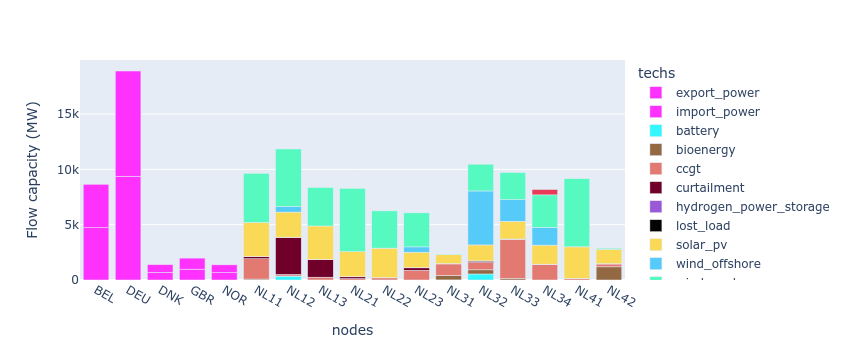

In [24]:
plot_capacity('results/spores/spore_baseline.nc', exclude_transmission=True, colors=colours)

[2026-02-26 17:34:20] INFO     Model: preprocessing data (reentry)
[2026-02-26 17:34:20] INFO     Math build | building applied math with ['base'].


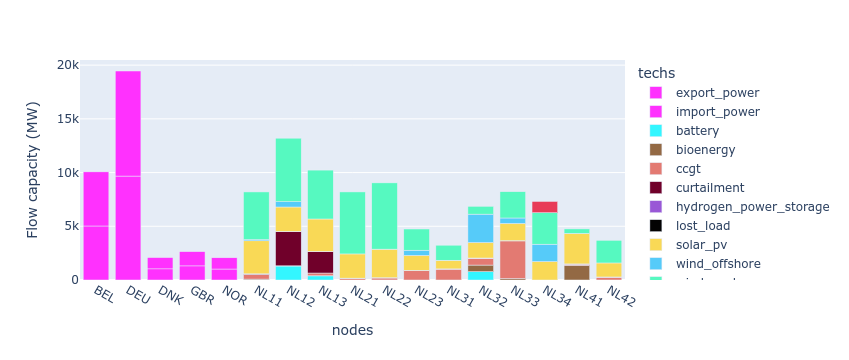

In [25]:
plot_capacity('results/spores/spore_1.nc', exclude_transmission=True, colors=colours)

[2026-02-26 17:34:21] INFO     Model: preprocessing data (reentry)
[2026-02-26 17:34:21] INFO     Math build | building applied math with ['base'].


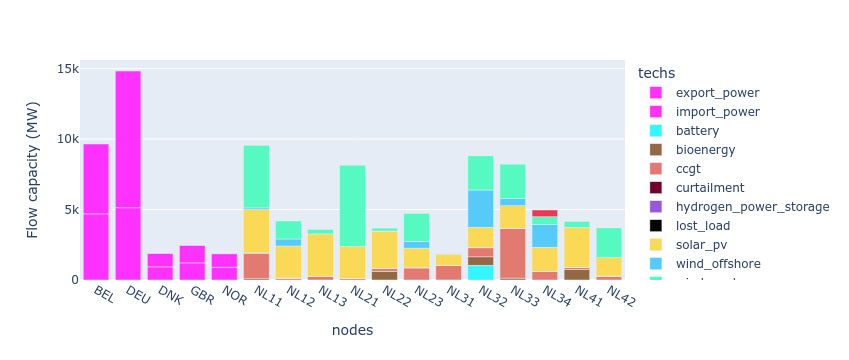

In [26]:
plot_capacity('results/spores/spore_2.nc', exclude_transmission=True, colors=colours)

[2026-02-26 17:34:24] INFO     Model: preprocessing data (reentry)
[2026-02-26 17:34:24] INFO     Math build | building applied math with ['base'].


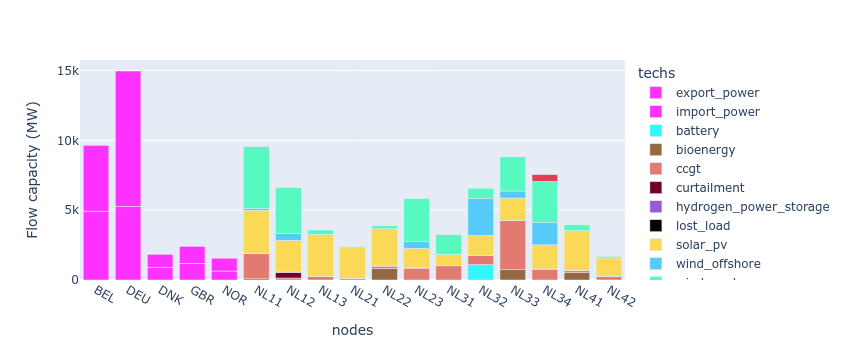

In [27]:
plot_capacity('results/spores/spore_5.nc', exclude_transmission=True, colors=colours)

## 3. Run the SPORES algorithm while intensifying system features of interest
As outlined in [Lombardi et al. (2023)](https://doi.org/10.1016/j.apenergy.2023.121002), SPORES are most effective when run in many parallel runs, each of which generates design options around 'intensified' system features, such as the degree of deployment of solar or wind power generation capacity. Here is an example of how to set up a parallel run for SPORES around intensified (maximised) battery capacity.

In [14]:
# Loading model files - although we initialise the SPORES in the scenarios, 
# they are not used yet. As in Section 2, SPORES will be used only when 
# calling the algorithm explicitly.
nuts2_model_spores_intensify = calliope.read_yaml('model_files/nuts2_model.yaml', 
                                    scenario='brownfield_capacities,transmission_150x,demand_2030,spores_mode_intensify_max,define_intensified_and_spores_techs')

[2026-02-26 17:32:19] INFO     (scenarios, brownfield_capacities,transmission_150x,demand_2030,spores_mode_intensify_max,define_intensified_and_spores_techs ) | Applying the following overrides: ['brownfield_capacities', 'transmission_150x', 'demand_2030', 'define_intensified_and_spores_techs', 'spores_mode_intensify_max'].
[2026-02-26 17:32:19] INFO     Math init | loading pre-defined math.
[2026-02-26 17:32:19] INFO     Math init | loading math files {'storage_inter_cluster', 'spores', 'milp', 'base', 'operate', 'spores_math', 'additional_math'}.
[2026-02-26 17:32:19] INFO     Model: preprocessing data
[2026-02-26 17:32:19] INFO     Math build | building applied math with ['base', 'additional_math', 'spores_math'].
[2026-02-26 17:32:24] INFO     input data `spores_objective_cost_weights` not defined in model math; it will not be available in the optimisation problem.
[2026-02-26 17:32:24] INFO     input data `spores_tracker` not defined in model math; it will not be available in the 

In [15]:
nuts2_model_spores_intensify.build()
nuts2_model_spores_intensify.solve()

[2026-02-26 17:32:25] INFO     Model: backend build starting
[2026-02-26 17:32:26] INFO     Optimisation Model | parameters/lookups | Generated.
[2026-02-26 17:32:26] INFO     Optimisation Model | variables | Generated.
[2026-02-26 17:32:29] INFO     Optimisation Model | global_expressions | Generated.
[2026-02-26 17:32:35] INFO     Optimisation Model | constraints | Generated.
[2026-02-26 17:32:35] INFO     Optimisation Model | piecewise_constraints | Generated.
[2026-02-26 17:32:35] INFO     Optimisation Model | objectives | Generated.
[2026-02-26 17:32:35] INFO     Model: backend build complete
[2026-02-26 17:32:42] INFO     Optimisation model | starting model in base mode.
[2026-02-26 17:33:00] INFO     Backend: solver finished running. Time since start of solving optimisation problem: 0:00:17.460532
[2026-02-26 17:33:00] INFO     Postprocessing: applied zero threshold 1e-10 to model results.
[2026-02-26 17:33:00] INFO     Postprocessing: ended. Time since start of solving optimisa

In [39]:
spores_intensified_results, spores_intensified_scores, backend = run_spores(number_of_spores=3, 
                                                                           cost_optimal_model=nuts2_model_spores_intensify, 
                                                                           scoring_method='random')

[2026-02-26 17:39:47] INFO     Optimisation model | starting model in base mode.
[2026-02-26 17:39:57] INFO     Backend: solver finished running. Time since start of solving optimisation problem: 0:00:10.630190
[2026-02-26 17:39:58] INFO     Postprocessing: applied zero threshold 1e-10 to model results.
[2026-02-26 17:39:58] INFO     Postprocessing: ended. Time since start of solving optimisation problem: 0:00:10.708315
[2026-02-26 17:39:58] INFO     Backend: model solve completed. Time since start of solving optimisation problem: 0:00:10.708780
[2026-02-26 17:40:03] INFO     Optimisation model | starting model in base mode.
[2026-02-26 17:40:15] INFO     Backend: solver finished running. Time since start of solving optimisation problem: 0:00:11.913838
[2026-02-26 17:40:15] INFO     Postprocessing: applied zero threshold 1e-10 to model results.
[2026-02-26 17:40:15] INFO     Postprocessing: ended. Time since start of solving optimisation problem: 0:00:12.024967
[2026-02-26 17:40:15] IN

In [40]:
# Export the individual SPORES for later inspection or re-use
for sp in range(1,spores_intensified_results.sizes['spores']):
    spores_intensified_results.sel(spores=sp).to_netcdf('results/spores/maxbat_spore_{}.nc'.format(sp))

### 3.1 Check that the SPORES intensify the desired feature and generate diversity around it 

In [41]:
colors = nuts2_model_spores_intensify.inputs.color.to_series().to_dict()

[2026-02-26 17:40:40] INFO     Model: preprocessing data (reentry)
[2026-02-26 17:40:40] INFO     Math build | building applied math with ['base'].


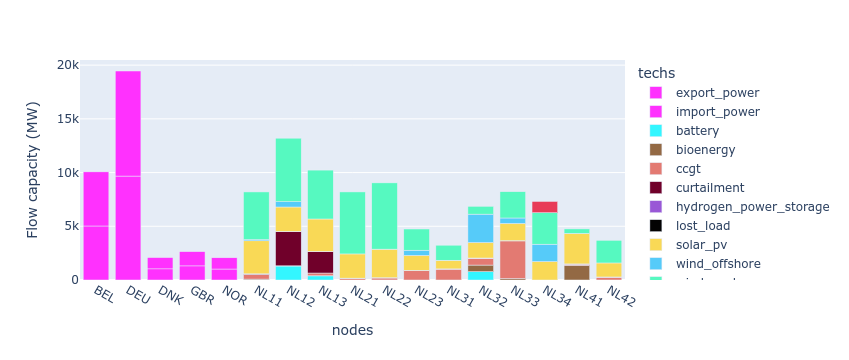

In [42]:
plot_capacity('results/spores/spore_1.nc', exclude_transmission=True, colors=colours)

[2026-02-26 17:40:40] INFO     Model: preprocessing data (reentry)
[2026-02-26 17:40:40] INFO     Math build | building applied math with ['base'].


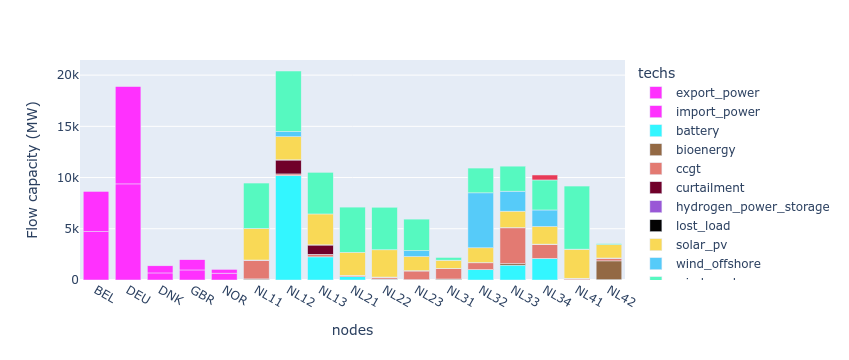

In [43]:
plot_capacity('results/spores/maxbat_spore_1.nc', exclude_transmission=True, colors=colours)

In [44]:
plot_capacity('results/spores/maxbat_spore_2.nc', exclude_transmission=True, colors=colours)

[2026-02-26 17:40:41] INFO     Model: preprocessing data (reentry)
[2026-02-26 17:40:41] INFO     Math build | building applied math with ['base'].


In [45]:
plot_capacity('results/spores/maxbat_spore_3.nc', exclude_transmission=True, colors=colours)

[2026-02-26 17:40:41] INFO     Model: preprocessing data (reentry)
[2026-02-26 17:40:41] INFO     Math build | building applied math with ['base'].
